In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from fcapy.context import FormalContext

In [4]:
df = pd.read_csv('books_binary.csv')

TARGET_COLUMN = "is_bestseller"

# Features (exclude id, title, author, target)
feature_cols = [
    'pages_gt_300', 'pages_gt_500', 'year_recent', 'year_classic',
    'genre_fiction', 'genre_nonfiction', 'genre_fantasy', 'genre_mystery',
    'genre_children', 'author_russian', 'is_popular', 'part_of_series'
]

data = pd.read_csv("books_binary.csv")

X = data[feature_cols]
y = data[TARGET_COLUMN]

# ВАЖНО: Строковые индексы для FCA
X.index = X.index.astype(str)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# Сохраняем строковые индексы после split
X_train.index = X_train.index.astype(str)
X_test.index = X_test.index.astype(str)

print(f"Dataset: {len(data)} books")
print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"Bestsellers: {y.sum()} ({y.sum()/len(y)*100:.1f}%)")



Dataset: 374 books
Train: 280, Test: 94
Bestsellers: 55 (14.7%)


In [10]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report

models = {
    # 1. kNN - требует стандартизации
    "kNN": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier())
        ]),
        {
            "model__n_neighbors": [3, 5, 7, 9],
            "model__weights": ["uniform", "distance"],
            "model__metric": ["euclidean", "manhattan"]
        }
    ),

    # 2. Naive Bayes - без стандартизации
    "Naive Bayes": (
        GaussianNB(),
        {
            "var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6]
        }
    ),

    # 3. Logistic Regression - требует стандартизации
        "Logistic Regression": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=1000, random_state=42))
        ]),
        {
            "model__C": [0.01, 0.1, 1, 10],
            "model__penalty": ["l2"],
            "model__class_weight": [None, "balanced"]
        }
    ),

    # 4. SVM - требует стандартизации
    "SVM": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC(random_state=42))
        ]),
        {
            "model__C": [0.1, 1, 10],
            "model__kernel": ["linear", "rbf"],
            "model__gamma": ["scale", "auto"],
            "model__class_weight": [None, "balanced"]
        }
    ),

    # 5. Decision Tree - без стандартизации
    "Decision Tree": (
        DecisionTreeClassifier(random_state=42),
        {
            "max_depth": [3, 5, 7, 10, None],
            "min_samples_split": [2, 5, 10],
            "criterion": ["gini", "entropy"],
            "class_weight": [None, "balanced"]
        }
    ),

    # 6. Random Forest - без стандартизации
    "Random Forest": (
        RandomForestClassifier(random_state=42),
        {
            "n_estimators": [100, 200],
            "max_depth": [5, 10, None],
            "min_samples_split": [2, 5],
            "class_weight": [None, "balanced", "balanced_subsample"]
        }
    )
}

print(f"\nDefined {len(models)} models with individual preprocessing")



Defined 6 models with individual preprocessing


In [49]:
results = []
best_models = {}

for name, (model, params) in models.items():
    print(f"Training: {name}")

    try:
        # Grid Search с кросс-валидацией
        grid = GridSearchCV(
            estimator=model,
            param_grid=params,
            cv=5,
            scoring="f1",
            n_jobs=-1,
            verbose=0
        )

        grid.fit(X_train, y_train)

        # Сохраняем лучшую модель
        best_models[name] = grid.best_estimator_

        # Прогноз на тесте
        y_pred = best_models[name].predict(X_test)

        # Вычисляем F1-score
        f1 = f1_score(y_test, y_pred)

        # Сохраняем результаты
        results.append({
            "Model": name,
            "F1-score": f1,
            "Best Params": grid.best_params_
        })

        print(f"Best parameters: {grid.best_params_}")
        print(f"F1-score on test: {f1:.4f}")

        # Подробный отчет
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))

    except Exception as e:
        print(f"ERROR training {name}: {e}")
        results.append({
            "Model": name,
            "F1-score": 0,
            "Best Params": "ERROR"
        })

Training: kNN
Best parameters: {'model__metric': 'euclidean', 'model__n_neighbors': 3, 'model__weights': 'distance'}
F1-score on test: 0.7200

Classification Report:
              precision    recall  f1-score   support

       False       0.94      0.97      0.96        80
        True       0.82      0.64      0.72        14

    accuracy                           0.93        94
   macro avg       0.88      0.81      0.84        94
weighted avg       0.92      0.93      0.92        94

Training: Naive Bayes
Best parameters: {'var_smoothing': 1e-09}
F1-score on test: 0.3607

Classification Report:
              precision    recall  f1-score   support

       False       0.94      0.55      0.69        80
        True       0.23      0.79      0.36        14

    accuracy                           0.59        94
   macro avg       0.59      0.67      0.53        94
weighted avg       0.83      0.59      0.64        94

Training: Logistic Regression
Best parameters: {'model__C': 1, 'mod

In [50]:
print("BASELINE MODELS COMPARISON")
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1-score", ascending=False)

for i, row in results_df.iterrows():
    print(f"{row['Model']:20s} | F1: {row['F1-score']:.4f}")

BASELINE MODELS COMPARISON
Logistic Regression  | F1: 0.8667
SVM                  | F1: 0.8667
Decision Tree        | F1: 0.8667
Random Forest        | F1: 0.8000
kNN                  | F1: 0.7200
Naive Bayes          | F1: 0.3607


In [13]:
from fcapy.context import FormalContext
from fcapy.lattice import ConceptLattice

# Create formal context
K_train = FormalContext.from_pandas(X_train)

# Build concept lattice
L = ConceptLattice.from_context(K_train, algo='Sofia', is_monotone=True)

print(f"Concept lattice: {len(L)} concepts")

/Users/mochalovskiy/hse/osda/big homework/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Concept lattice: 91 concepts


In [14]:
# Calculate F1-score for each concept
for c in L:
    y_preds = np.zeros(K_train.n_objects)
    y_preds[list(c.extent_i)] = 1
    c.measures['f1_score'] = f1_score(y_train, y_preds)

# Extract F1-scores into array
f1_scores = np.array([c.measures['f1_score'] for c in L])

# Select top-10 concepts
best_concepts = list(f1_scores.argsort()[::-1][:10])

print("Best concepts selected:", best_concepts)
print(f"Best F1-score: {f1_scores[best_concepts[0]]:.3f}")


Best concepts selected: [np.int64(15), np.int64(9), np.int64(20), np.int64(21), np.int64(13), np.int64(14), np.int64(26), np.int64(30), np.int64(18), np.int64(19)]
Best F1-score: 0.766


In [15]:
print("Best concepts indices:", best_concepts)
print("\nTop-5 concepts F1-scores:")
for i, idx in enumerate(best_concepts[:5]):
    concept = L[idx][0]  # Берем первый элемент кортежа!
    print(f"  {i+1}. Concept {idx}: F1={concept.measures['f1_score']:.3f}")
    print(f"      Intent: {concept.intent}")


Best concepts indices: [np.int64(15), np.int64(9), np.int64(20), np.int64(21), np.int64(13), np.int64(14), np.int64(26), np.int64(30), np.int64(18), np.int64(19)]

Top-5 concepts F1-scores:
  1. Concept 15: F1=0.766
      Intent: ('year_classic', 'author_russian', 'part_of_series')
  2. Concept 9: F1=0.750
      Intent: ('year_classic', 'author_russian')
  3. Concept 20: F1=0.683
      Intent: ('year_classic', 'genre_fantasy', 'author_russian', 'part_of_series')
  4. Concept 21: F1=0.672
      Intent: ('year_classic', 'genre_children', 'author_russian', 'part_of_series')
  5. Concept 13: F1=0.653
      Intent: ('year_classic', 'genre_fantasy', 'author_russian')


In [16]:
print("y_train unique values:", y_train.unique())
print("y_train value counts:")
print(y_train.value_counts())

print("\nX_train shape:", X_train.shape)
print("X_train dtypes:")
print(X_train.dtypes)

print("\nSample X_train:")
print(X_train.head())


y_train unique values: [False  True]
y_train value counts:
is_bestseller
False    239
True      41
Name: count, dtype: int64

X_train shape: (280, 12)
X_train dtypes:
pages_gt_300        bool
pages_gt_500        bool
year_recent         bool
year_classic        bool
genre_fiction       bool
genre_nonfiction    bool
genre_fantasy       bool
genre_mystery       bool
genre_children      bool
author_russian      bool
is_popular          bool
part_of_series      bool
dtype: object

Sample X_train:
     pages_gt_300  pages_gt_500  year_recent  year_classic  genre_fiction  \
306          True          True        False         False          False   
60           True          True        False          True          False   
348          True         False         True         False          False   
82          False         False         True         False          False   
359          True         False         True         False          False   

     genre_nonfiction  genre_fantasy  g

Please, modify the ``pos`` dictionary parameter manually. You can obtain the default ``pos`` via Mover.initialize_pos(...) function.

The problematic edges and nodes (in the form of {edge: overlapped nodes indexes}) are:
{(86, 90): frozenset({88, 84})}


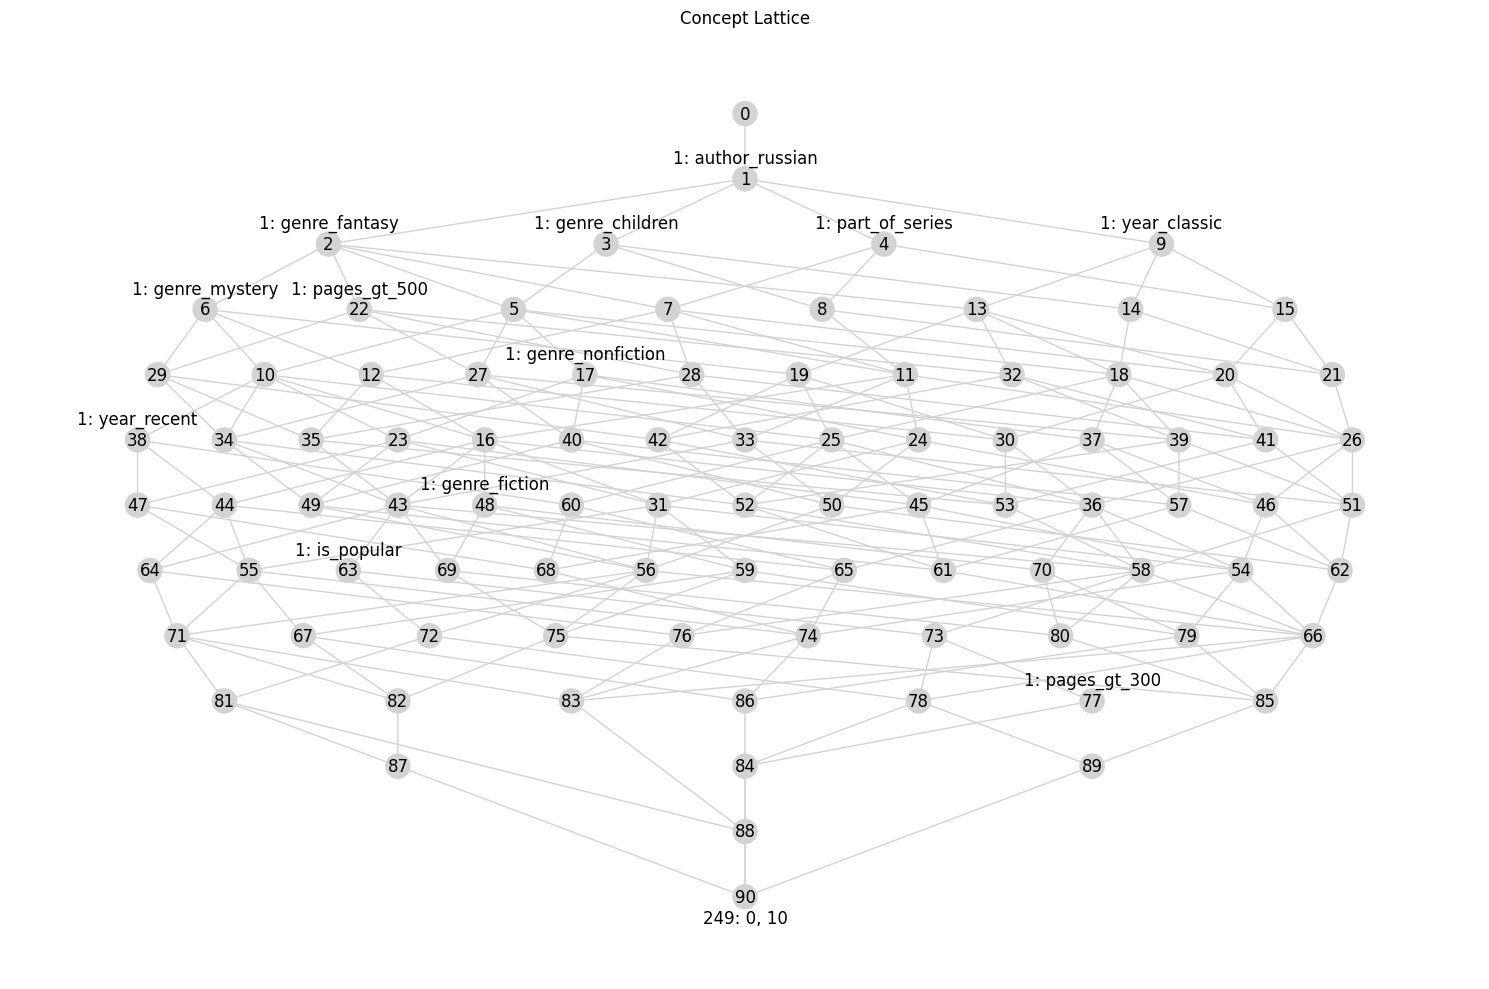

In [60]:
from fcapy.visualizer import LineVizNx

fig, ax = plt.subplots(figsize=(15, 10))
vis = LineVizNx()
vis.draw_concept_lattice(L, ax=ax, flg_node_indices=True)
ax.set_title('Concept Lattice')
plt.tight_layout()
plt.show()

In [17]:
import neural_lib58 as nl

y_train_int = y_train.astype(int)
y_test_int = y_test.astype(int)

# Create network (targets должны быть int)
cn = nl.ConceptNetwork.from_lattice(L, best_concepts, [0, 1])

# Train
f1_list_test = []
f1_list_train = []

for i in range(10):
    if i == 0:
        cn.fit(X_train, y_train_int, 500)
    else:
        cn.fit_2(X_train, y_train_int, 500)

    pred_test = cn.predict(X_test)[1]
    pred_train = cn.predict(X_train)[1]

    f1_test = f1_score(y_test_int, pred_test)
    f1_train = f1_score(y_train_int, pred_train)

    f1_list_test.append(f1_test)
    f1_list_train.append(f1_train)

    print(f'Epoch {(i+1)*500}: Test F1={f1_test:.3f}, Train F1={f1_train:.3f}')

print(f"\nFinal Neural FCA F1-score: {f1_list_test[-1]:.3f}")

Epoch 500: Test F1=0.000, Train F1=0.000
Epoch 1000: Test F1=0.000, Train F1=0.000
Epoch 1500: Test F1=0.000, Train F1=0.000
Epoch 2000: Test F1=0.000, Train F1=0.000
Epoch 2500: Test F1=0.000, Train F1=0.000
Epoch 3000: Test F1=0.000, Train F1=0.000
Epoch 3500: Test F1=0.000, Train F1=0.000
Epoch 4000: Test F1=0.000, Train F1=0.000
Epoch 4500: Test F1=0.000, Train F1=0.000
Epoch 5000: Test F1=0.000, Train F1=0.000

Final Neural FCA F1-score: 0.000


### Neural lib improved

In [19]:
import neural_lib_improved as nl

y_train_int = y_train.astype(int)
y_test_int = y_test.astype(int)

# Create network
cn = nl.ConceptNetwork.from_lattice(L, best_concepts, [0, 1])

# Train
f1_list_test = []
f1_list_train = []

for i in range(10):
    if i == 0:
        cn.fit(X_train, y_train_int, 500)
    else:
        cn.fit_2(X_train, y_train_int, 500)

    pred_test = cn.predict(X_test)[1]
    pred_train = cn.predict(X_train)[1]

    f1_test = f1_score(y_test_int, pred_test)
    f1_train = f1_score(y_train_int, pred_train)

    f1_list_test.append(f1_test)
    f1_list_train.append(f1_train)

    print(f'Epoch {(i+1)*500}: Test F1={f1_test:.3f}, Train F1={f1_train:.3f}')

print(f"\nFinal Neural FCA F1-score: {f1_list_test[-1]:.3f}")

Epoch 500: Test F1=0.867, Train F1=0.953
Epoch 1000: Test F1=0.867, Train F1=0.953
Epoch 1500: Test F1=0.867, Train F1=0.953
Epoch 2000: Test F1=0.867, Train F1=0.953
Epoch 2500: Test F1=0.867, Train F1=0.953
Epoch 3000: Test F1=0.867, Train F1=0.953
Epoch 3500: Test F1=0.867, Train F1=0.953
Epoch 4000: Test F1=0.867, Train F1=0.953
Epoch 4500: Test F1=0.867, Train F1=0.953
Epoch 5000: Test F1=0.867, Train F1=0.953

Final Neural FCA F1-score: 0.867


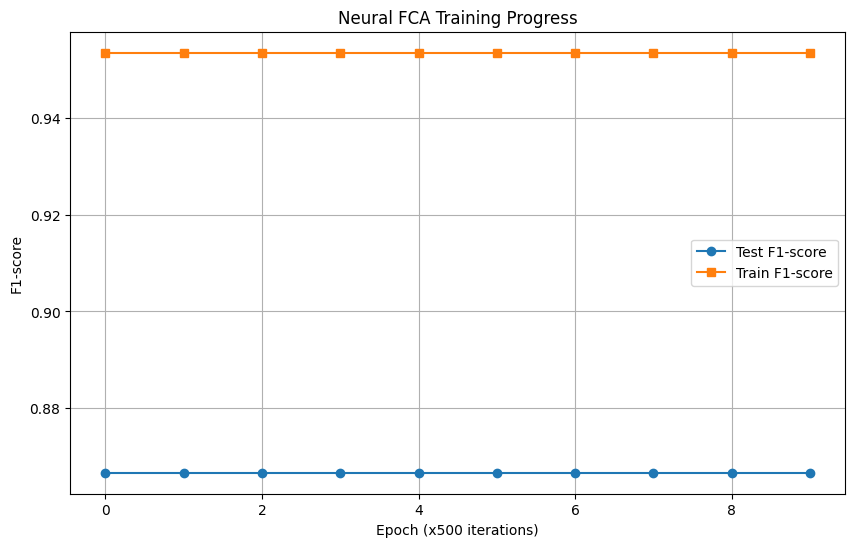

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(f1_list_test, label='Test F1-score', marker='o')
plt.plot(f1_list_train, label='Train F1-score', marker='s')
plt.xlabel('Epoch (x500 iterations)')
plt.ylabel('F1-score')
plt.title('Neural FCA Training Progress')
plt.legend()
plt.grid(True)
plt.show()

### Multiple Page Thresholds

Instead of 2 thresholds (300, 500), use 5 thresholds (200, 300, 400, 500, 600) for better granularity.

In [22]:
# Load raw data to create improved binarization
df_raw = pd.read_csv('books_raw.csv')

# Create improved features with multiple page thresholds
X_v2 = pd.DataFrame()

# 5 page thresholds (was 2)
X_v2['pages_gt_200'] = df_raw['pages'] > 200
X_v2['pages_gt_300'] = df_raw['pages'] > 300
X_v2['pages_gt_400'] = df_raw['pages'] > 400
X_v2['pages_gt_500'] = df_raw['pages'] > 500
X_v2['pages_gt_600'] = df_raw['pages'] > 600

# 4 decade-based years (was 2)
X_v2['year_pre1950'] = (df_raw['year'] < 1950) & (df_raw['year'] > 0)
X_v2['year_1950_1999'] = (df_raw['year'] >= 1950) & (df_raw['year'] < 2000)
X_v2['year_2000_2014'] = (df_raw['year'] >= 2000) & (df_raw['year'] < 2015)
X_v2['year_2015plus'] = df_raw['year'] >= 2015

# Keep same genre features
for col in ['genre_fiction', 'genre_nonfiction', 'genre_fantasy', 'genre_mystery', 'genre_children']:
    X_v2[col] = df[col]

# Keep other features
X_v2['author_russian'] = df['author_russian']
X_v2['is_popular'] = df['is_popular']
X_v2['part_of_series'] = df['part_of_series']

# String indices for FCA
X_v2.index = X_v2.index.astype(str)

print(f"Improved features: {len(X_v2.columns)}")


Improved features: 17


In [23]:
# Split improved dataset
X_v2_train, X_v2_test, y_v2_train, y_v2_test = train_test_split(
    X_v2, y, test_size=0.25, random_state=42, stratify=y
)

X_v2_train.index = X_v2_train.index.astype(str)
X_v2_test.index = X_v2_test.index.astype(str)

# Build lattice with improved features
K_v2_train = FormalContext.from_pandas(X_v2_train)
L_v2 = ConceptLattice.from_context(K_v2_train, algo='Sofia', is_monotone=True)

print(f"Improved lattice: {len(L_v2)} concepts (was {len(L)})")

# Select best concepts
for c in L_v2:
    y_preds = np.zeros(K_v2_train.n_objects)
    y_preds[list(c.extent_i)] = 1
    c.measures['f1_score'] = f1_score(y_v2_train.astype(int), y_preds)

f1_scores_v2 = np.array([c.measures['f1_score'] for c in L_v2])
best_concepts_v2 = list(f1_scores_v2.argsort()[::-1][:10])

print(f"Best concept F1: {f1_scores_v2[best_concepts_v2[0]]:.3f}")

# Train Neural FCA with improved features
import neural_lib_improved as nl

cn_v2 = nl.ConceptNetwork.from_lattice(L_v2, best_concepts_v2, [0, 1])
cn_v2.fit(X_v2_train, y_v2_train.astype(int), 1000)

pred_v2 = cn_v2.predict(X_v2_test)[1]
f1_v2 = f1_score(y_v2_test.astype(int), pred_v2)

print(f"\nOriginal binarization: F1 = 0.867")
print(f"Improved binarization: F1 = {f1_v2:.3f}")
print(f"Difference: {f1_v2 - 0.867:+.3f}")


Improved lattice: 88 concepts (was 91)
Best concept F1: 0.612

Original binarization: F1 = 0.867
Improved binarization: F1 = 0.897
Difference: +0.030


In [41]:
# Weighted selection: F1 + extent size
def select_weighted(L, y_train, k=10):
    scores = []

    for c in L:
        # Normalize extent size to [0, 1]
        extent_size_norm = len(c.extent_i) / len(y_train)

        # Combined score: 80% F1 + 20% extent size
        weighted_score = 0.85 * c.measures['f1_score'] + 0.15 * extent_size_norm
        scores.append(weighted_score)

    scores = np.array(scores)
    return list(scores.argsort()[::-1][:k])

best_weighted = select_weighted(L_v2, y_v2_train, k=10)

print(f"Weighted selection: {best_weighted}")
print(f"F1-based:           {best_concepts_v2}")
print(f"Overlap: {len(set(best_weighted) & set(best_concepts_v2))}/10")

# Train
cn_weighted = nl.ConceptNetwork.from_lattice(L_v2, best_weighted, [0, 1])
cn_weighted.fit(X_v2_train, y_v2_train.astype(int), 1000)

pred_weighted = cn_weighted.predict(X_v2_test)[1]
f1_weighted = f1_score(y_v2_test.astype(int), pred_weighted)

print(f"\nF1-based: F1 = {f1_v2:.3f}")
print(f"Weighted: F1 = {f1_weighted:.3f}")
print(f"Difference: {f1_weighted - f1_v2:+.3f}")


Weighted selection: [np.int64(11), np.int64(6), np.int64(15), np.int64(20), np.int64(10), np.int64(24), np.int64(25), np.int64(29), np.int64(14), np.int64(18)]
F1-based:           [np.int64(11), np.int64(6), np.int64(15), np.int64(10), np.int64(20), np.int64(25), np.int64(24), np.int64(14), np.int64(29), np.int64(18)]
Overlap: 10/10

F1-based: F1 = 0.897
Weighted: F1 = 0.929
Difference: +0.032


### Baseline Models on Improved Dataset

Re-train all baseline ML models on improved binarization (X_v2) for fair comparison.


In [73]:
# Train baseline models on improved dataset
results_v2 = []

for name, (model, params) in models.items():
    print(f"{name}...", end=" ")

    try:
        grid = GridSearchCV(model, params, cv=5, scoring="f1", n_jobs=-1)
        grid.fit(X_v2_train, y_v2_train)

        y_pred = grid.best_estimator_.predict(X_v2_test)
        f1 = f1_score(y_v2_test, y_pred)

        results_v2.append([name, f1, grid.best_params_ ])
        print(f"F1={f1:.3f}")

    except Exception as e:
        print(f"ERROR")
        results_v2.append([name, 0])

print(f"\nDone: {len(results_v2)} models")

kNN... F1=0.800
Naive Bayes... F1=0.440
Logistic Regression... F1=0.897
SVM... F1=0.867
Decision Tree... F1=0.867
Random Forest... F1=0.783

Done: 6 models


In [79]:
# Final comparison table
print("FINAL COMPARISON")

print("\nOriginal dataset (12 features):")
print(results_df.sort_values('F1-score', ascending=False).to_string(index=False))


print("\nImproved dataset (18 features):")
results_v2_df = pd.DataFrame(results_v2, columns=["Model", "F1-score", "Best Params"])

# Add Neural FCA to improved dataset results
results_v2_with_neural = results_v2.copy()
results_v2_with_neural.append(['Neural FCA (weighted selection)', f1_weighted])
results_v2_neural_df = pd.DataFrame(results_v2_with_neural, columns=["Model", "F1-score", "Best Params"])

print(results_v2_neural_df.sort_values('F1-score', ascending=False).to_string(index=False))

# Best from each
best_orig = results_df['F1-score'].max()
best_v2 = results_v2_df['F1-score'].max()

print(f"\nBest baseline (original):  {best_orig:.3f}")
print(f"Best baseline (improved):  {best_v2:.3f}")
print(f"Neural FCA:         {f1_weighted:.3f}")

print(f"\nNeural FCA advantage: +{f1_weighted - best_v2:.3f} (+{(f1_weighted-best_v2)/best_v2*100:.1f}%)")


FINAL COMPARISON

Original dataset (12 features):
              Model  F1-score                                                                                              Best Params
Logistic Regression  0.866667                               {'model__C': 1, 'model__class_weight': 'balanced', 'model__penalty': 'l2'}
                SVM  0.866667 {'model__C': 0.1, 'model__class_weight': 'balanced', 'model__gamma': 'scale', 'model__kernel': 'linear'}
      Decision Tree  0.866667                {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}
      Random Forest  0.800000                      {'class_weight': None, 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
                kNN  0.720000                    {'model__metric': 'euclidean', 'model__n_neighbors': 3, 'model__weights': 'distance'}
        Naive Bayes  0.360656                                                                                 {'var_smoothing': 1e-09}

Impr

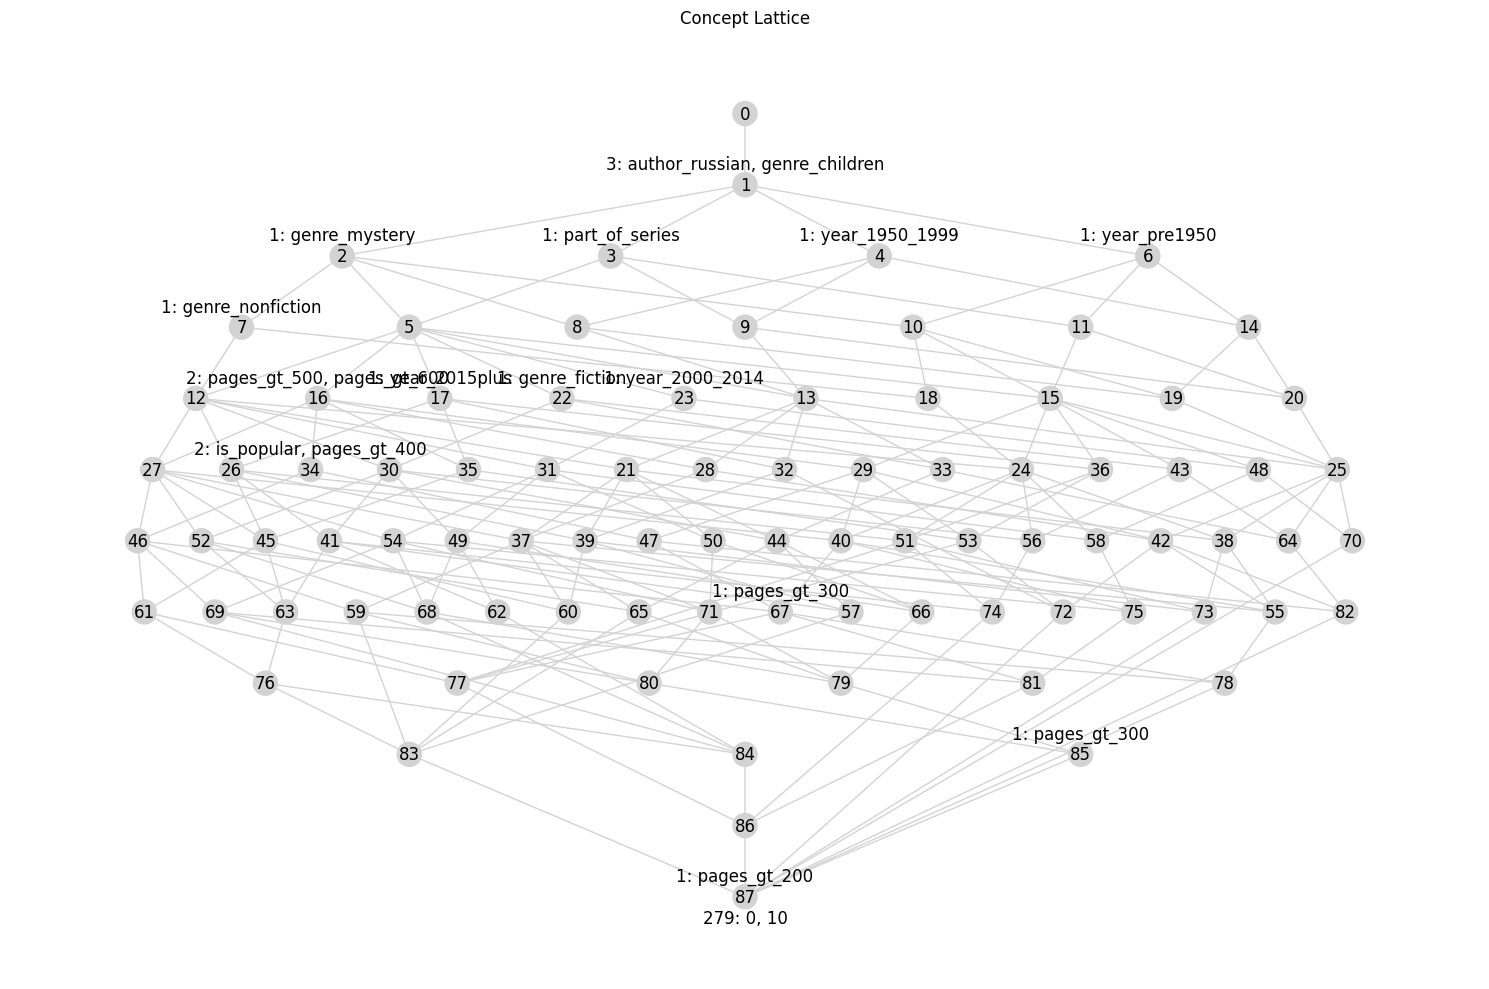

In [65]:
from fcapy.visualizer import LineVizNx

fig, ax = plt.subplots(figsize=(15, 10))
vis = LineVizNx()
vis.draw_concept_lattice(L_v2, ax=ax, flg_node_indices=True)
ax.set_title('Concept Lattice')
plt.tight_layout()
plt.show()

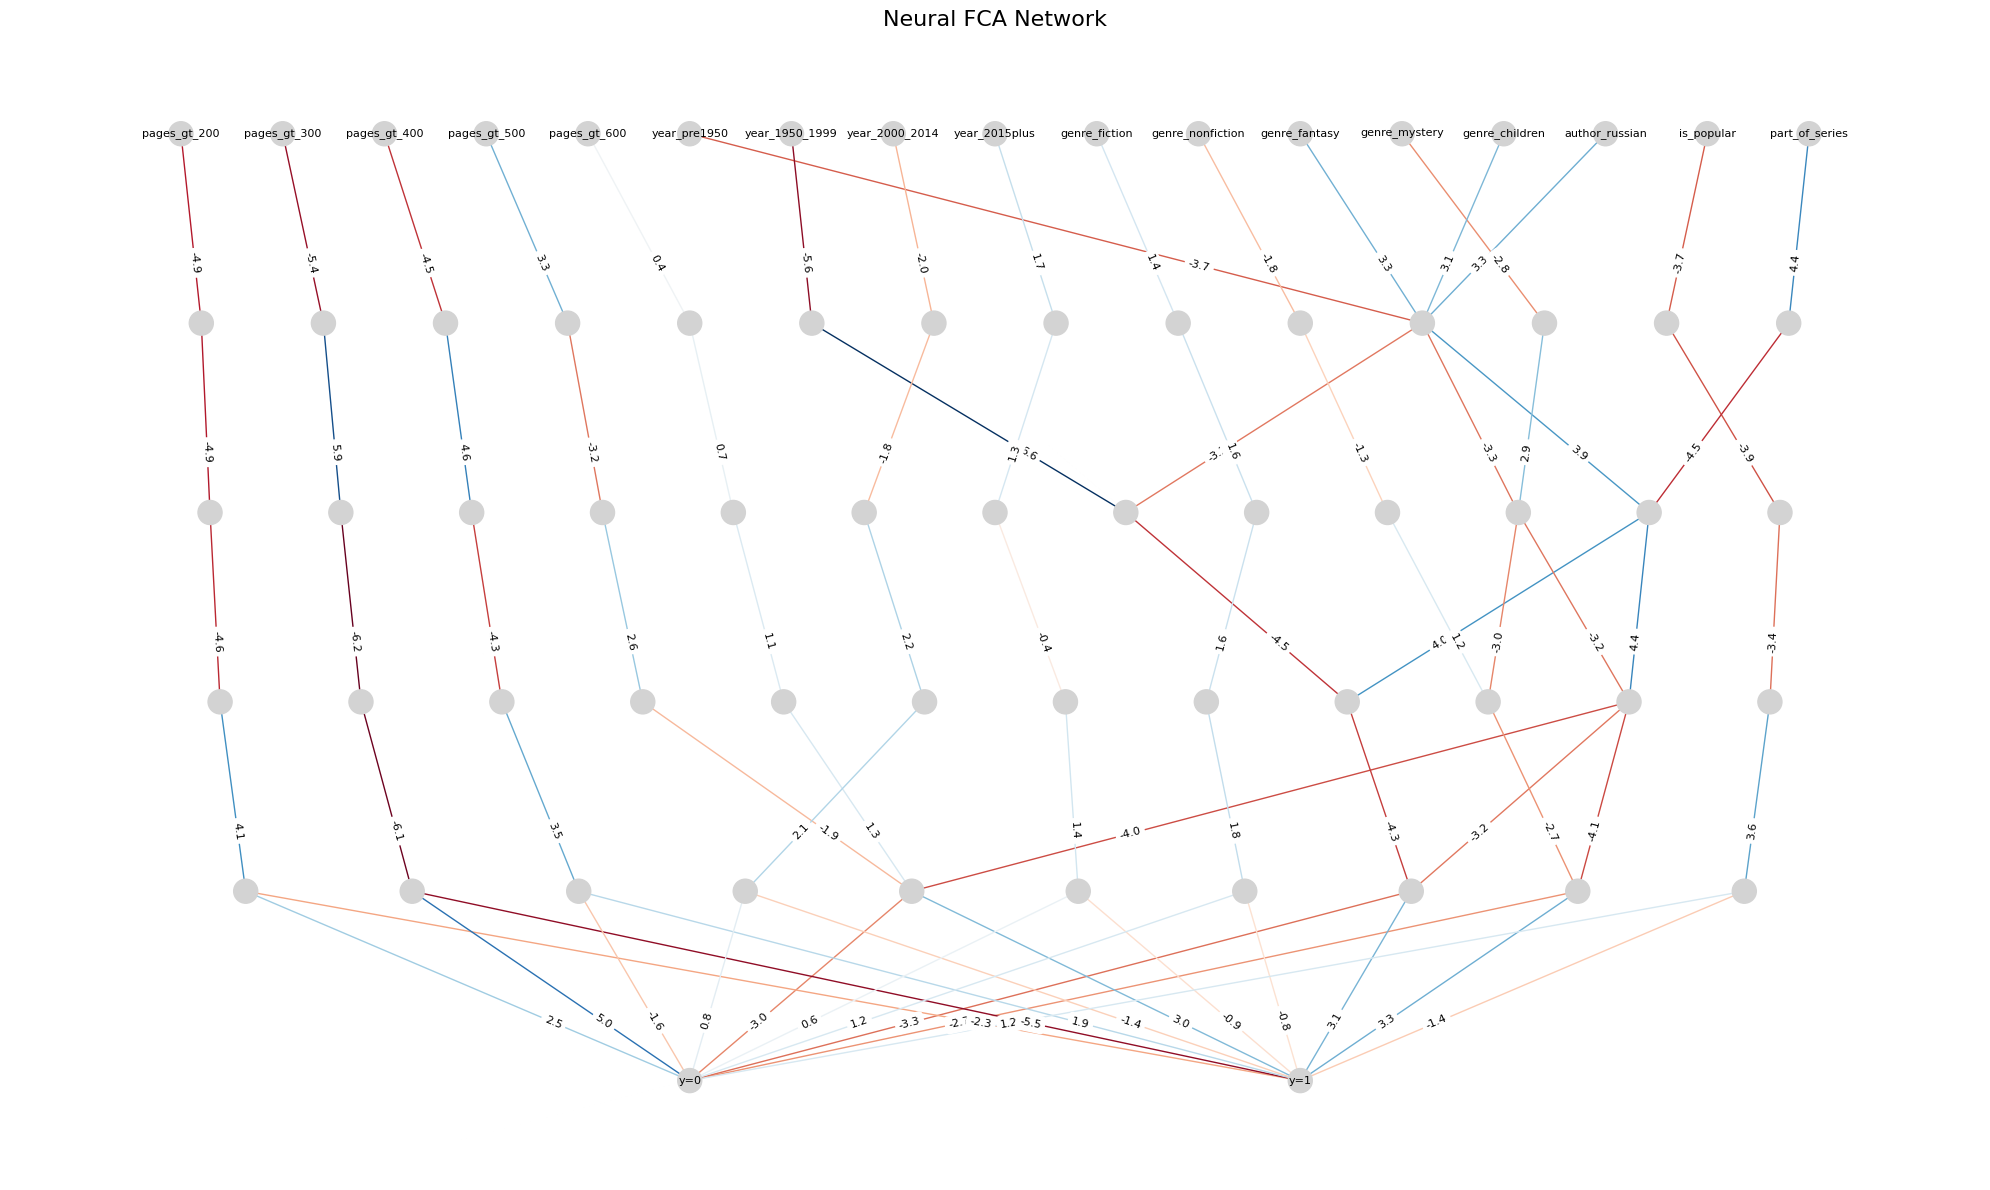

In [72]:
import networkx as nx
from fcapy.visualizer import LineVizNx

edge_weights = cn_weighted.edge_weights_from_network()

fig, ax = plt.subplots(figsize=(20, 12))
vis = LineVizNx(
    node_label_font_size=8,
    node_label_func=lambda el_i, P: nl.neuron_label_func(
        el_i, P, set(cn_weighted.attributes), only_new_attrs=True
    )
)

vis.draw_poset(
    cn_weighted.poset, ax=ax,
    flg_node_indices=False,
    edge_color=[edge_weights[e] for e in cn_weighted.poset.to_networkx().edges],
    edge_cmap=plt.cm.RdBu,
)

nx.draw_networkx_edge_labels(
    cn_weighted.poset.to_networkx(), vis.mover.pos,
    {k: f"{v:.1f}" for k, v in edge_weights.items()},
    label_pos=0.7,
    font_size=8
)

plt.title(f'Neural FCA Network', size=16)
plt.tight_layout()
plt.show()


In [ ]:
print("Best concepts analysis:")
for i, idx in enumerate(best_concepts):
    concept = L[idx][0]
    print(f"\n{i+1}. Concept {idx}:")
    print(f"   Intent: {concept.intent}")
    print(f"   Extent size: {len(concept.extent_i)}")
    print(f"   F1-score: {concept.measures['f1_score']:.3f}")

Best concepts analysis:

1. Concept 15:
   Intent: ('year_classic', 'author_russian', 'part_of_series')
   Extent size: 66
   F1-score: 0.766

2. Concept 9:
   Intent: ('year_classic', 'author_russian')
   Extent size: 47
   F1-score: 0.750

3. Concept 20:
   Intent: ('year_classic', 'genre_fantasy', 'author_russian', 'part_of_series')
   Extent size: 79
   F1-score: 0.683

4. Concept 21:
   Intent: ('year_classic', 'genre_children', 'author_russian', 'part_of_series')
   Extent size: 81
   F1-score: 0.672

5. Concept 13:
   Intent: ('year_classic', 'genre_fantasy', 'author_russian')
   Extent size: 60
   F1-score: 0.653

6. Concept 14:
   Intent: ('year_classic', 'genre_children', 'author_russian')
   Extent size: 62
   F1-score: 0.641

7. Concept 26:
   Intent: ('year_classic', 'genre_fantasy', 'genre_children', 'author_russian', 'part_of_series')
   Extent size: 93
   F1-score: 0.612

8. Concept 30:
   Intent: ('year_classic', 'genre_fantasy', 'genre_mystery', 'author_russian', 'par